In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("./output/survey_cleaned_final.csv").reset_index()
df.head()

,index,Dấu thời gian,doi_tuong,dia_diem,mon_gioi,mon_yeu,diem_gan_nhat,to_hop_clean,diem_du_doan,muc_dich,target_list,khao_khat_clean
0,0,2026/03/24 7:09:52 CH GMT+7,Lớp 12,Miền Nam,[],[],[8.0 - 9.0),['A00'],[24 - 27),Xét tuyển bằng điểm thi THPTQG,"['Vị thế tương đối', 'Xác suất ""an toàn""']",NaN
1,1,2026/03/24 10:27:40 CH GMT+7,Lớp 11,Miền Nam,[],[],[8.0 - 9.0),['A01'],[24 - 27),Xét tuyển bằng điểm thi THPTQG,"['Vị thế tương đối', 'Xác suất ""an toàn""', 'So...",em mong muốn được vỡ oà cảm xúc sau những chặn...
2,2,2026/03/24 10:28:35 CH GMT+7,Lớp 12,Miền Nam,[],[],[8.0 - 9.0),"['D01', 'A01']",[18 - 21),Xét tuyển bằng điểm thi THPTQG,"['Xác suất ""an toàn""']",Biết mình đậu hay ki
3,3,2026/03/25 5:50:08 CH GMT+7,Đã tốt nghiệp THPT,Miền Trung,[],[],[9.0 - 10.0],['A00'],[27 - 30),Lấy điểm để đi du học hoặc xét tuyển riêng.,['Phân tích phổ điểm'],Nụ cười của cha mẹ
4,4,2026/03/26 11:29:09 SA GMT+7,Đã tốt nghiệp THPT,Miền Trung,"['Hóa', 'Toán']","['Sinh', 'Văn', 'Anh']",[8.0 - 9.0),['A00'],[24 - 27),Xét tuyển bằng điểm thi THPTQG,"['Phân tích phổ điểm', 'So sánh tổ hợp']",NaN


# 1. Phân loại đối tượng

In [2]:
result_1 = df.groupby("doi_tuong", as_index=False).agg({"index": "count"}).rename(columns={
    "index": "Số lượng",
    "doi_tuong": "Loại đối tượng"
})

print(result_1)

       Loại đối tượng  Số lượng
0              Lớp 10       138
1              Lớp 11        16
2              Lớp 12        23
3  Đã tốt nghiệp THPT        32


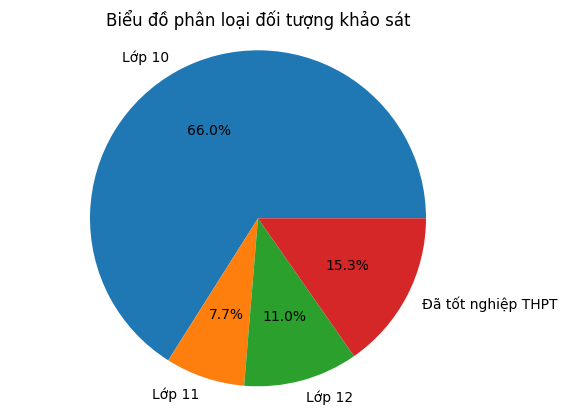

In [3]:
plt.pie(
    x = result_1["Số lượng"], 
    labels = result_1["Loại đối tượng"], 
    autopct='%1.1f%%'
)

plt.title("Biểu đồ phân loại đối tượng khảo sát")
plt.axis('equal')
plt.savefig("./output/classifying_object.png")
plt.show()

# 2. Phân loại đối tượng theo vị trí địa lý

In [4]:
result_2 = df.groupby("dia_diem", as_index=False).agg({"index": "count"}).rename(columns={
    "index": "Số lượng",
    "dia_diem": "Khu vực"
})

print(result_2)

      Khu vực  Số lượng
0    Miền Bắc        13
1    Miền Nam       184
2  Miền Trung        12


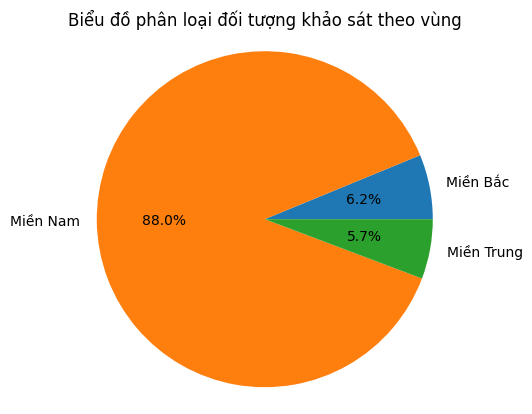

In [5]:
plt.pie(
    x = result_2["Số lượng"], 
    labels = result_2["Khu vực"], 
    autopct='%1.1f%%'
)

plt.title("Biểu đồ phân loại đối tượng khảo sát theo vùng")
plt.axis('equal')
plt.savefig("./output/region.png")
plt.show()

# 3. Phân tích về các môn thi của các thí sinh

## a. Môn giỏi

In [6]:
import ast 

table_mon_gioi = df["mon_gioi"].astype(str).apply(ast.literal_eval).explode().dropna()
table_mon_gioi

4       Hóa
4      Toán
5       Hóa
5        Lý
6      Sinh
       ... 
206    Toán
207      Lý
207     Anh
207    Toán
208     Anh
Name: mon_gioi, Length: 484, dtype: str

In [7]:
result_3a = table_mon_gioi.value_counts().reset_index().rename(columns={
    "mon_gioi": "Môn",
    "count": "Số lượng" 
})

print(result_3a)

                      Môn  Số lượng
0                    Toán        98
1                     Anh        92
2                     Văn        79
3                     Hóa        55
4                      Lý        46
5                     Địa        31
6                    Sinh        29
7                      Sử        27
8                     Tin        13
9     GDKT&PL (Hoặc GDCD)        11
10  Công nghệ công nghiệp         3


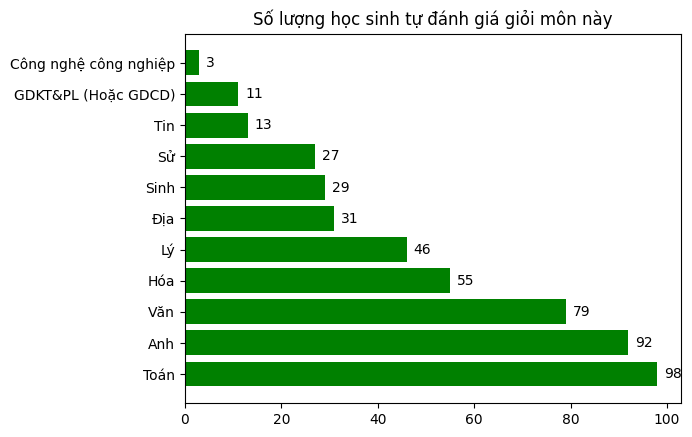

In [8]:
bars = plt.barh(
    y=result_3a["Môn"], 
    width=result_3a["Số lượng"], 
    color='green'
)

plt.bar_label(bars, padding=5)


plt.title("Số lượng học sinh tự đánh giá giỏi môn này")
plt.show()

## b. Môn không giỏi

In [9]:
table_mon_yeu = df["mon_yeu"].astype(str).apply(ast.literal_eval).explode().dropna()
table_mon_yeu

4                     Sinh
4                      Văn
4                      Anh
5                      Anh
5                     Toán
              ...         
206    GDKT&PL (Hoặc GDCD)
206                    Địa
206                    Anh
207                   Toán
208                   Toán
Name: mon_yeu, Length: 467, dtype: str

In [10]:
result_3b = table_mon_yeu.value_counts().reset_index().rename(columns={
    "mon_yeu": "Môn",
    "count": "Số lượng" 
})

print(result_3b)

                      Môn  Số lượng
0                    Toán        94
1                      Lý        68
2                     Anh        53
3                     Văn        46
4                     Hóa        46
5                    Sinh        45
6                     Tin        28
7     GDKT&PL (Hoặc GDCD)        22
8                      Sử        19
9                     Địa        17
10  Công nghệ nông nghiệp        15
11  Công nghệ công nghiệp        14


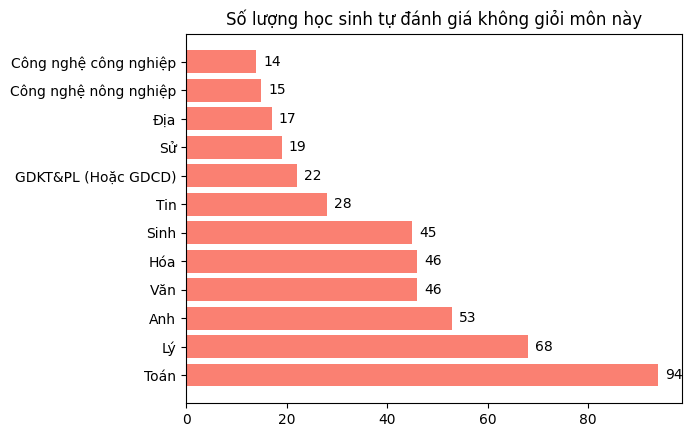

In [11]:
# Vẽ biểu đồ cột ngang
bars = plt.barh(
    y=result_3b["Môn"], 
    width=result_3b["Số lượng"], 
    color='salmon'
)

plt.bar_label(bars, padding=5)

plt.title("Số lượng học sinh tự đánh giá không giỏi môn này")
plt.show()

## 3. So sánh 2 biểu đồ

In [12]:
df_compare = result_3a.merge(result_3b, on="Môn", how="outer", suffixes=(' giỏi', ' không giỏi'))

df_compare = df_compare.fillna(0)

df_compare[["Số lượng giỏi", "Số lượng không giỏi"]] = df_compare[["Số lượng giỏi", "Số lượng không giỏi"]].astype(int)

df_compare

,Môn,Số lượng giỏi,Số lượng không giỏi
0,Anh,92,53
1,Công nghệ công nghiệp,3,14
2,Công nghệ nông nghiệp,0,15
3,GDKT&PL (Hoặc GDCD),11,22
4,Hóa,55,46
5,Lý,46,68
6,Sinh,29,45
7,Sử,27,19
8,Tin,13,28
9,Toán,98,94


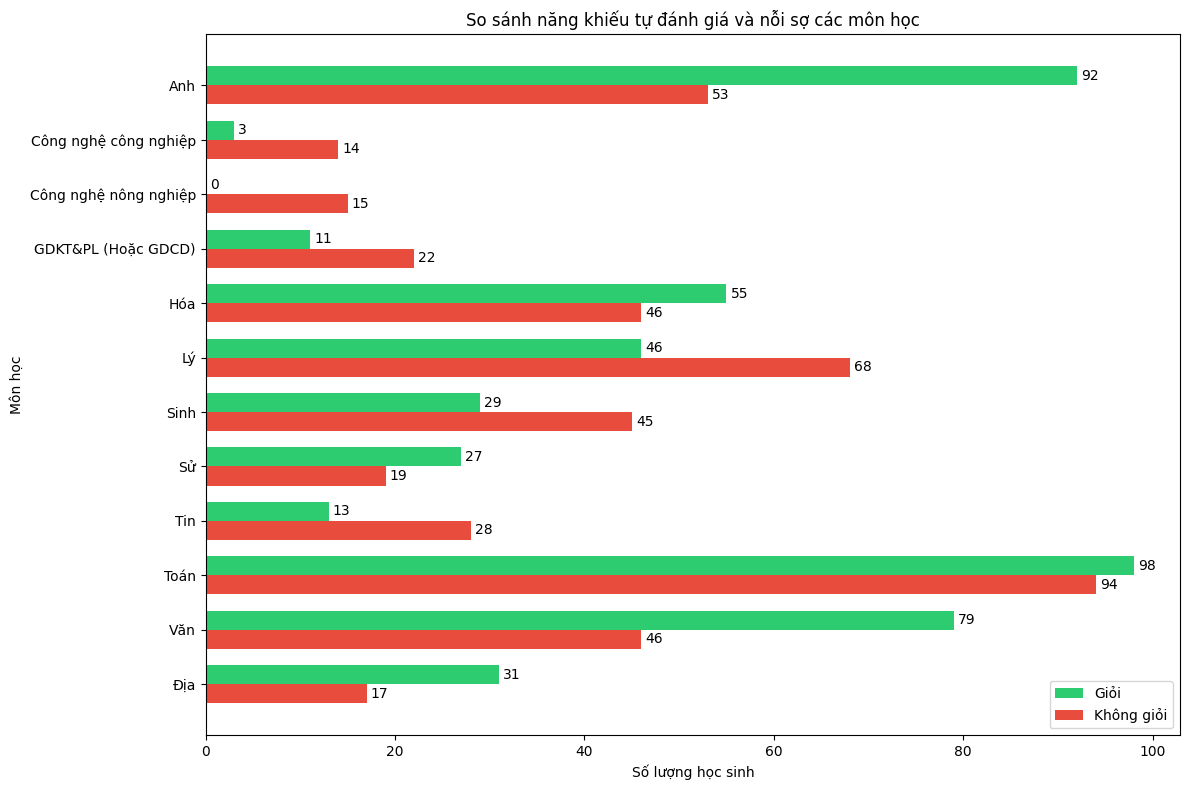

In [13]:
# Thiết lập vị trí các cột
y = np.arange(len(df_compare))
width = 0.35  # Độ rộng của mỗi cột

fig, ax = plt.subplots(figsize=(12, 8))

# Vẽ cột Giỏi
rects1 = ax.barh(y - width/2, df_compare["Số lượng giỏi"], width, label='Giỏi', color='#2ecc71')

# Vẽ cột Không giỏi
rects2 = ax.barh(y + width/2, df_compare["Số lượng không giỏi"], width, label='Không giỏi', color='#e74c3c')

# Thêm nhãn và trang trí
ax.set_ylabel('Môn học')
ax.set_xlabel('Số lượng học sinh')
ax.set_title('So sánh năng khiếu tự đánh giá và nỗi sợ các môn học')
ax.set_yticks(y)
ax.set_yticklabels(df_compare["Môn"])
ax.legend()

# Thêm con số lên đầu cột để dễ đọc
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.gca().invert_yaxis()  # Môn nhiều người giỏi nhất nằm trên cùng
plt.tight_layout()
plt.savefig("./output/compare_table.png")
plt.show()

# 4. Mục đích thi

In [14]:
result_4 = df["muc_dich"].value_counts().reset_index()
result_4

,muc_dich,count
0,Xét tuyển bằng điểm thi THPTQG,129
1,Lấy điểm để đi du học hoặc xét tuyển riêng.,32
2,Đủ điều kiện xét học bạ / ĐGNL,28
3,Khác,14
4,Chỉ để xét tốt nghiệp THPT / Thi cho có,6


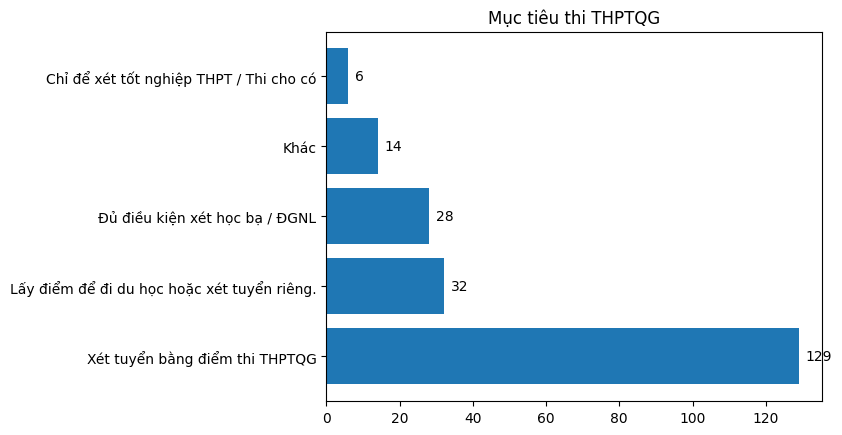

In [15]:
bars = plt.barh(
    width = result_4["count"], 
    y = result_4["muc_dich"]
)

plt.bar_label(bars, padding=5)

plt.title("Mục tiêu thi THPTQG")
plt.savefig("./output/purposes.png")
plt.show()

# 5. Điểm số

In [16]:
# Hoặc dùng dấu & thay cho and
table_5 = df[["diem_gan_nhat", "diem_du_doan"]].query(
    "(diem_gan_nhat != 'Khác') & (diem_du_doan != 'Khác')"
).replace({"[27 - 30)" : "[27 - 30]"})

table_5

,diem_gan_nhat,diem_du_doan
0,[8.0 - 9.0),[24 - 27)
1,[8.0 - 9.0),[24 - 27)
2,[8.0 - 9.0),[18 - 21)
3,[9.0 - 10.0],[27 - 30]
4,[8.0 - 9.0),[24 - 27)
...,...,...
204,[8.0 - 9.0),[24 - 27)
205,Mình ngại lắm / Không muốn trả lời,[21 - 24)
206,[9.0 - 10.0],[27 - 30]
207,[7.0 - 8.0),[21 - 24)


In [17]:
table_5["diem_du_doan"].unique()

<StringArray>
['[24 - 27)', '[18 - 21)', '[27 - 30]', '[21 - 24)', '[15 - 18)']
Length: 5, dtype: str

In [18]:
valid_scores_nearest = ['[5.0 - 6.0)', '[6.0 - 7.0)', '[7.0 - 8.0)', '[8.0 - 9.0)', '[9.0 - 10.0]']
valid_scores_predict = ['[24 - 27)', '[18 - 21)', '[27 - 30)', '[21 - 24)', '[27 - 30]', '[15 - 18)']

# Lọc table_4
table_5_clean = table_5[
    table_5['diem_gan_nhat'].isin(valid_scores_nearest) & 
    table_5['diem_du_doan'].isin(valid_scores_predict)
]

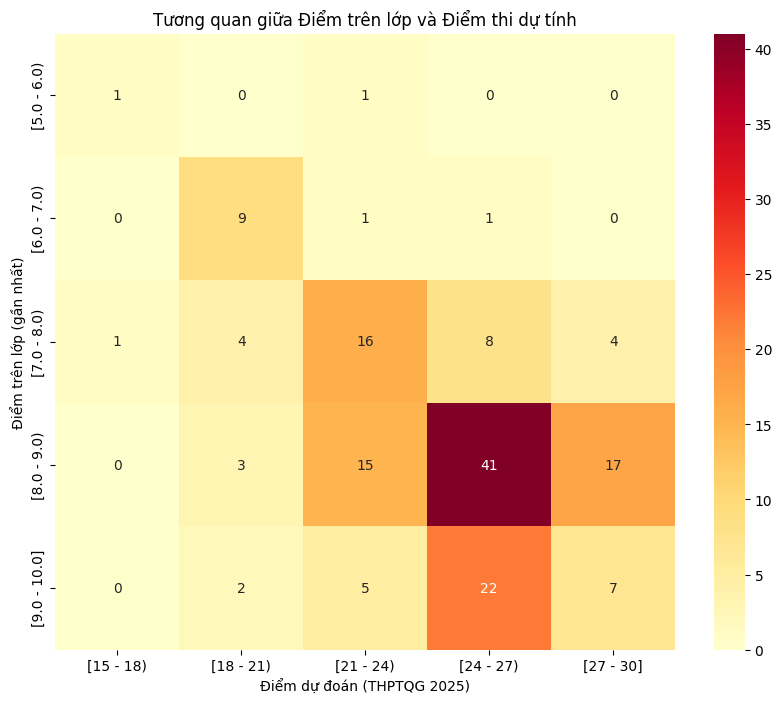

In [19]:
ct = pd.crosstab(
    index=table_5_clean["diem_gan_nhat"], 
    columns=table_5_clean["diem_du_doan"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Tương quan giữa Điểm trên lớp và Điểm thi dự tính")
plt.ylabel("Điểm trên lớp (gần nhất)")
plt.xlabel("Điểm dự đoán (THPTQG 2025)")
plt.savefig("./output/score_related.png")
plt.show()

# 6. Mong muốn khi có trang dashboard

## a. Mong muốn chính

### - Độ độc lập của các mong muốn

In [20]:
target = ['Xác suất "an toàn"', 'Phân tích phổ điểm', 'Vị thế tương đối', 'Thứ hạng ước tính', 'So sánh tổ hợp']

# Khởi tạo table_6a riêng biệt để tránh lỗi tham chiếu ngược
table_6a_series = df["target_list"].astype(str).apply(ast.literal_eval).explode().dropna()
table_6a = table_6a_series[table_6a_series.isin(target)]
table_6a

0        Vị thế tương đối
0      Xác suất "an toàn"
1        Vị thế tương đối
1      Xác suất "an toàn"
1          So sánh tổ hợp
              ...        
205     Thứ hạng ước tính
206        So sánh tổ hợp
207    Xác suất "an toàn"
207        So sánh tổ hợp
208    Xác suất "an toàn"
Name: target_list, Length: 372, dtype: str

In [21]:
table_6a_group_by = table_6a.value_counts().reset_index()

# Đổi tên cột cho rõ ràng để đưa vào tiểu luận
table_6a_group_by.columns = ['Tính năng kỳ vọng', 'Số lượt chọn']

table_6a_group_by

,Tính năng kỳ vọng,Số lượt chọn
0,"Xác suất ""an toàn""",150
1,Phân tích phổ điểm,63
2,Vị thế tương đối,60
3,Thứ hạng ước tính,56
4,So sánh tổ hợp,43


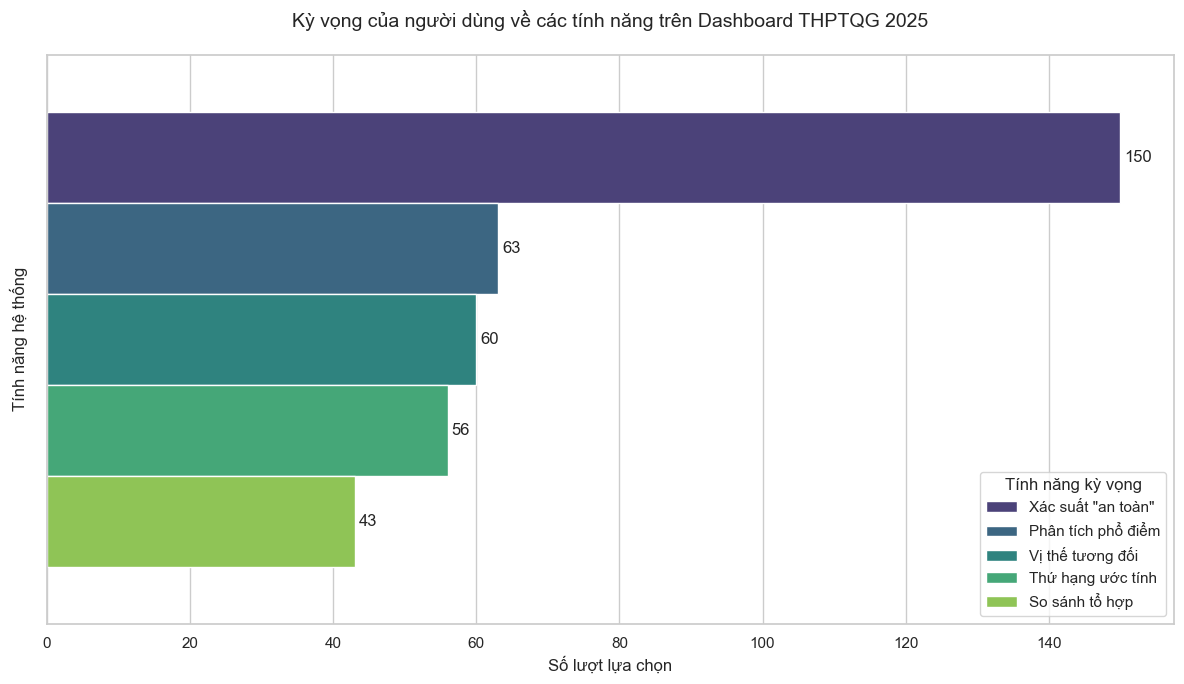

In [22]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ cột ngang để tên các tính năng không bị chồng lấp
ax = sns.barplot(
    x='Số lượt chọn', 
    hue='Tính năng kỳ vọng', 
    data=table_6a_group_by, 
    palette='viridis'
)

# Thêm con số cụ thể lên đầu mỗi cột
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('Kỳ vọng của người dùng về các tính năng trên Dashboard THPTQG 2025', fontsize=14, pad=20)
plt.xlabel('Số lượt lựa chọn', fontsize=12)
plt.ylabel('Tính năng hệ thống', fontsize=12)
plt.tight_layout()
plt.savefig("./output/main-purposes.png")
plt.show()

### - Độ liên kết giữa các bình chọn

In [23]:
table_6b = table_6a.copy()

# B1: Quy đổi bảng thành dạng wide
dummies = pd.get_dummies(table_6a)

# B2: Gán boolean vào các giá trị tương ứng 
table_6b_boolean = dummies.groupby(level=0).max().astype(bool)

# B3: Loại bỏ những người chọn 0-1 bình chọn 
table_6b_link = table_6b_boolean[table_6b_boolean.sum(axis=1) >= 2]

# Kiểm tra lại kích thước mẫu sau khi lọc
print(f"Số lượng mẫu ban đầu: {len(table_6b_boolean)}")
print(f"Số lượng mẫu đủ điều kiện phân tích liên kết (>=2 lựa chọn): {len(table_6b_link)}")
print(table_6b_link.head())


Số lượng mẫu ban đầu: 208
Số lượng mẫu đủ điều kiện phân tích liên kết (>=2 lựa chọn): 78
   Phân tích phổ điểm  So sánh tổ hợp  Thứ hạng ước tính  Vị thế tương đối  \
0               False           False              False              True   
1               False            True              False              True   
4                True            True              False             False   
5                True           False               True              True   
6                True           False               True             False   

   Xác suất "an toàn"  
0                True  
1                True  
4               False  
5                True  
6               False  


In [24]:
from mlxtend.frequent_patterns import apriori, association_rules

# Tìm các tập phổ biến
frequent_itemsets = apriori(table_6b_link, min_support=0.1, use_colnames=True)

# Tạo các luật kết hợp
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Sắp xếp theo độ tin cậy (Confidence)
rules = rules.sort_values(by="confidence", ascending=False)

In [25]:
# Chọn 5 cột quan trọng và lấy 10 dòng đầu tiên
top_rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

# Làm đẹp dữ liệu (chuyển frozenset sang chuỗi) để dễ đưa vào tiểu luận
top_rules["antecedents"] = top_rules["antecedents"].apply(lambda x: ', '.join(list(x)))
top_rules["consequents"] = top_rules["consequents"].apply(lambda x: ', '.join(list(x)))

# Sử dụng .style.format để định dạng các cột số
top_rules_styled = top_rules.style.format({
    'support': '{:.3f}',    # Lấy 3 chữ số thập phân
    'confidence': '{:.3f}', # Lấy 3 chữ số thập phân
    'lift': '{:.3f}'        # Lấy 3 chữ số thập phân
})

# Hiển thị kết quả
top_rules_styled

,antecedents,consequents,support,confidence,lift
140,"Vị thế tương đối, Phân tích phổ điểm, So sánh tổ hợp, Thứ hạng ước tính","Xác suất ""an toàn""",0.192,1.000,1.238
109,"Vị thế tương đối, Phân tích phổ điểm, Thứ hạng ước tính","Xác suất ""an toàn""",0.244,0.950,1.176
82,"Phân tích phổ điểm, So sánh tổ hợp, Thứ hạng ước tính","Xác suất ""an toàn""",0.218,0.944,1.169
123,"Vị thế tương đối, Thứ hạng ước tính, So sánh tổ hợp","Xác suất ""an toàn""",0.205,0.941,1.165
138,"Vị thế tương đối, Thứ hạng ước tính, Xác suất ""an toàn"", So sánh tổ hợp",Phân tích phổ điểm,0.192,0.938,1.463
51,"Thứ hạng ước tính, So sánh tổ hợp","Xác suất ""an toàn""",0.244,0.905,1.120
96,"Vị thế tương đối, Xác suất ""an toàn"", So sánh tổ hợp",Phân tích phổ điểm,0.231,0.900,1.404
83,"Thứ hạng ước tính, Xác suất ""an toàn"", So sánh tổ hợp",Phân tích phổ điểm,0.218,0.895,1.396
60,"Vị thế tương đối, Thứ hạng ước tính","Xác suất ""an toàn""",0.308,0.889,1.101
68,"Vị thế tương đối, Thứ hạng ước tính, So sánh tổ hợp",Phân tích phổ điểm,0.192,0.882,1.376


In [26]:
top_rules_styled.to_excel("./output/required.xlsx")

## b. Mục tiêu phụ

In [27]:
table_6c = df["khao_khat_clean"].dropna()
table_6c.shape

(87,)

In [28]:
from wordcloud import WordCloud
from underthesea import word_tokenize

In [29]:
clean_6c = (
    table_6c.astype(str).str.strip()
    .replace({
        r"\bnv\b": "nguyện vọng",
        r"\bTP\b": "thành phố",
        r"\btp\b": "thành phố",
        r"\bThành phố\b": "thành phố",
    }, regex=True)
)

# Loại bỏ các giá trị rác đặc thù
dead_values = ['nan', 'None', '.', '..', '...', 'khong', 'không', 'ko', 'Không', 'Không có']
final_6c = clean_6c[
    (clean_6c.map(len) > 1) & 
    (~clean_6c.isin(dead_values))
]

# Dùng underthesea để nối các cụm từ quan trọng như "đỗ_vọng_1", "tổ_hợp_môn"
text_processed_6c = [word_tokenize(sentence, format="text") for sentence in final_6c]

# Gộp lại
full_text_6c = " ".join(text_processed_6c)

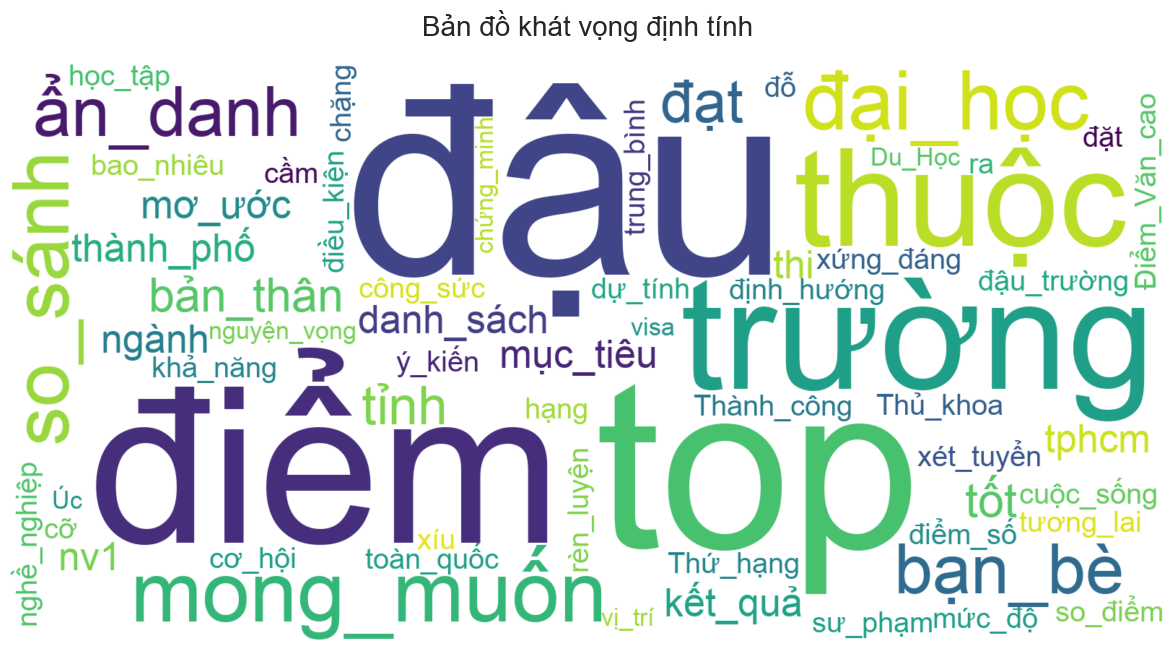

In [30]:
sclass_stopwords = set([
    "là", "và", "của", "mình", "em", "có", "được", "muốn", "khi", "trong",
    "cho", "với", "con", "biết", "như", "nào", "gì", "này", "cũng", "đang",
    "còn", "thì", "tại", "về", "các", "những", "cái", "đã", "sẽ", "nhưng",
    "là_một", "của_mình", "em_muốn", "cho_con", "cũng_như", "không", "khonho",
    "tôi", "bt", "người", "mọi", "mà", "học cầm", "Shbsbaah", "ko", "Khomg", "bạn",
    "ngôi", "thêm", "òa", "cười", "kh", "muốn", "để", "chỉ", "vỡ", "ở", "Khômg",
    "sau", "bước", "thấy", "r", "Kh", "qua", "có_thuộc", "hay", "một_cách", "k", "cha_mẹ",
    "nếu", "thôi", "dạ", "ngủ", "chung", "anh_chị", "môt", "hơn", "muốnp", "nghỉ",
    "so", "bè", "đâu", "khác", "Nếu", "cùng", "dc", "học", "nhất", 'nằm', "đó",
    "cả", "K", "ki", "rồi", "biết", "ạ", "môn", "tiếp", "Nụ", "ban", "anh", "tình",
    "ạ", "hè", "trên", "hết", "THPTQG", "khao_khát", "cảm_xúc", "chưa", "ba_mẹ", "khoe",
    "muôn", "muon", "dài", "vào", "biet", "chọn", "cách", "mỏi_mệt", "viết", "Chúc", "muon",
    "nước", "tới", "nhìn", "trải", "đường", "mấy", "năng_lực", "lớp", "hơn_nữa", "ao_ước",
    "đưa", "mong", "xem", "số", "văn", "đứng", "cao", "trả_lời", "sau_này",
    "ức", "đủ", "nha", "cần", "làm", "Thứ", "khoảng", "có_thể", "bao_nhuieu",
    "cần", "khoảng", "đủ", "làm", "co_thuoc"
])


wordcloud_6c = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    colormap='viridis',
    font_path='./input/arial.ttf',  # Đường dẫn bạn vừa cấu hình
    stopwords=sclass_stopwords,      # Sử dụng bộ lọc bạn đã xây dựng
    collocations=False,
    max_words=100
).generate(full_text_6c)

# --- BƯỚC 4: HIỂN THỊ ---
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud_6c, interpolation='bilinear')
plt.axis("off")
plt.title("Bản đồ khát vọng định tính", fontsize=20, pad=20)
plt.savefig("./output/optional.png")
plt.show()

# Kết luận chung

## 1. Chân dung người dùng mục tiêu (User Profile)

- Dữ liệu từ `./output/classifying_object.png` và `./output/region.png` cho thấy một bức tranh rất rõ ràng:

- Đối tượng trọng tâm: Nhóm học sinh lớp 10 chiếm ưu thế tuyệt đối (66.0%). Đây là nhóm khách hàng "mới" của chương trình giáo dục 2025, đang đối mặt với áp lực chọn môn và định hướng sớm.

- Phạm vi địa lý: Đại đa số đến từ Miền Nam (88.0%).

=> Kiến nghị: Dashboard cần ưu tiên ngôn ngữ trẻ trung, giao diện tối giản và nội dung hướng dẫn tập trung vào việc chọn tổ hợp môn cho khối lớp 10.

## 2. Phân tích nhu cầu cốt lõi (Core Needs)

- Dựa trên biểu đồ `./output/main-purposes.png` và WordCloud từ `./output/optional.jpg`:

- Nhu cầu lớn nhất: Tính năng Xác suất "an toàn" đạt số lượt chọn cao nhất (150 lượt).

- Tâm lý thí sinh: Các từ khóa như "Trường top", "Đậu", "Điểm" xuất hiện với kích thước lớn nhất trong WordCloud.

- Hành vi đặc biệt: Sự xuất hiện của từ "Ẩn danh" trong phản hồi định tính cho thấy người dùng rất quan tâm đến quyền riêng tư khi tra cứu điểm số.

## 3. Khai phá hành vi bằng Luật kết hợp (Association Rules)

Kết quả từ thuật toán Apriori trên 78 mẫu chất lượng nhất cho thấy các "cặp bài trùng" tính năng:

- Luật 140 (Confidence 1.000): 100% người dùng quan tâm đến Thứ hạng, Vị thế và Phổ điểm sẽ yêu cầu thêm tính năng Xác suất an toàn.

- Liên kết mạnh (Lift ~1.46): Nhu cầu So sánh tổ hợp luôn đi đôi với việc Phân tích phổ điểm.

=> Kiến nghị thiết kế UI/UX: Không nên tách rời các tính năng này. Khi hiển thị Phổ điểm, hệ thống nên có một widget dự báo Xác suất an toàn ngay bên cạnh để tối ưu trải nghiệm người dùng.

## 4. Đánh giá tính khả thi và Hướng phát triển

- Tương quan điểm số: Biểu đồ heatmap `./output/score_related_2.png` cho thấy sự tập trung dày đặc ở ngưỡng điểm `[24 - 27]`, chứng tỏ nhóm người dùng phần lớn là học sinh khá giỏi.

- Mục tiêu: 129/208 người dùng xác định mục tiêu cao nhất là kỳ thi THPTQG.

- Hướng đi tiếp theo: Tích hợp thêm AI để tư vấn lộ trình học dựa trên "nỗi sợ" môn học (ví dụ: Toán, Lý có tỷ lệ "Không giỏi" khá cao trong `./output/compare_table.png`).